In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# ==========================================
# Import Required Libraries
# ==========================================

import os
import random
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

warnings.filterwarnings("ignore")

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [9]:
# ==========================================
# Dataset Paths
# ==========================================

PROJECT_PATH = "/content/drive/MyDrive/Diabetic-Retinopathy-Detection/dataset"

TRAIN_CSV = os.path.join(PROJECT_PATH, "train_1.csv")
VALID_CSV = os.path.join(PROJECT_PATH, "valid.csv")
TEST_CSV = os.path.join(PROJECT_PATH, "test.csv")

TRAIN_DIR = os.path.join(PROJECT_PATH, "train_images", "train_images")
VALID_DIR = os.path.join(PROJECT_PATH, "val_images", "val_images")
TEST_DIR = os.path.join(PROJECT_PATH, "test_images", "test_images")

In [10]:
# ==========================================
# Verify Dataset Files
# ==========================================

print("Train CSV Exists :", os.path.exists(TRAIN_CSV))
print("Validation CSV Exists :", os.path.exists(VALID_CSV))
print("Test CSV Exists :", os.path.exists(TEST_CSV))

print()

print("Training Images :", len(os.listdir(TRAIN_DIR)))
print("Validation Images :", len(os.listdir(VALID_DIR)))
print("Testing Images :", len(os.listdir(TEST_DIR)))

Train CSV Exists : True
Validation CSV Exists : True
Test CSV Exists : True

Training Images : 2930
Validation Images : 366
Testing Images : 366


In [11]:
# ==========================================
# Load CSV Files
# ==========================================

train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)
test_df = pd.read_csv(TEST_CSV)

print(f"Training Samples   : {len(train_df)}")
print(f"Validation Samples : {len(valid_df)}")
print(f"Testing Samples    : {len(test_df)}")

Training Samples   : 2930
Validation Samples : 366
Testing Samples    : 366


In [12]:
train_df.head()

,id_code,diagnosis
0,1ae8c165fd53,2
1,1b329a127307,1
2,1b32e1d775ea,4
3,1b3647865779,0
4,1b398c0494d1,0


In [13]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_code    2930 non-null   object
 1   diagnosis  2930 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 45.9+ KB


In [14]:
train_df.isnull().sum()

,0
id_code,0
diagnosis,0


In [15]:
train_df.columns.tolist()

['id_code', 'diagnosis']

# 3. Exploratory Data Analysis (EDA)

In this section, we will:

- Check the distribution of diabetic retinopathy classes.
- Display sample retinal fundus images.
- Verify that image files match the CSV records.

In [16]:
# ==========================================
# Class Distribution
# ==========================================

class_counts = train_df["diagnosis"].value_counts().sort_index()

print(class_counts)

diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64


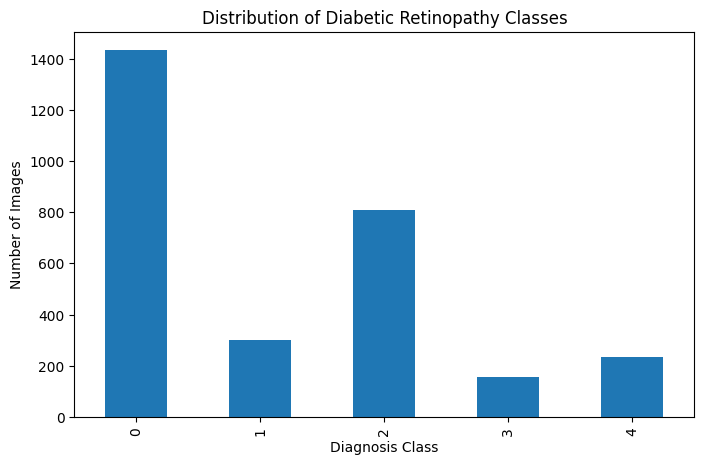

In [17]:
# ==========================================
# Plot Class Distribution
# ==========================================

plt.figure(figsize=(8,5))

class_counts.plot(kind="bar")

plt.title("Distribution of Diabetic Retinopathy Classes")
plt.xlabel("Diagnosis Class")
plt.ylabel("Number of Images")

plt.show()

In [18]:
# ==========================================
# Create Full Image Paths
# ==========================================

train_df["image_path"] = train_df["id_code"].apply(
    lambda x: os.path.join(TRAIN_DIR, x + ".png")
)

valid_df["image_path"] = valid_df["id_code"].apply(
    lambda x: os.path.join(VALID_DIR, x + ".png")
)

test_df["image_path"] = test_df["id_code"].apply(
    lambda x: os.path.join(TEST_DIR, x + ".png")
)

In [19]:
train_df.head()

,id_code,diagnosis,image_path
0,1ae8c165fd53,2,/content/drive/MyDrive/Diabetic-Retinopathy-De...
1,1b329a127307,1,/content/drive/MyDrive/Diabetic-Retinopathy-De...
2,1b32e1d775ea,4,/content/drive/MyDrive/Diabetic-Retinopathy-De...
3,1b3647865779,0,/content/drive/MyDrive/Diabetic-Retinopathy-De...
4,1b398c0494d1,0,/content/drive/MyDrive/Diabetic-Retinopathy-De...


In [20]:
missing = train_df[~train_df["image_path"].apply(os.path.exists)]

print("Missing Images:", len(missing))

Missing Images: 0


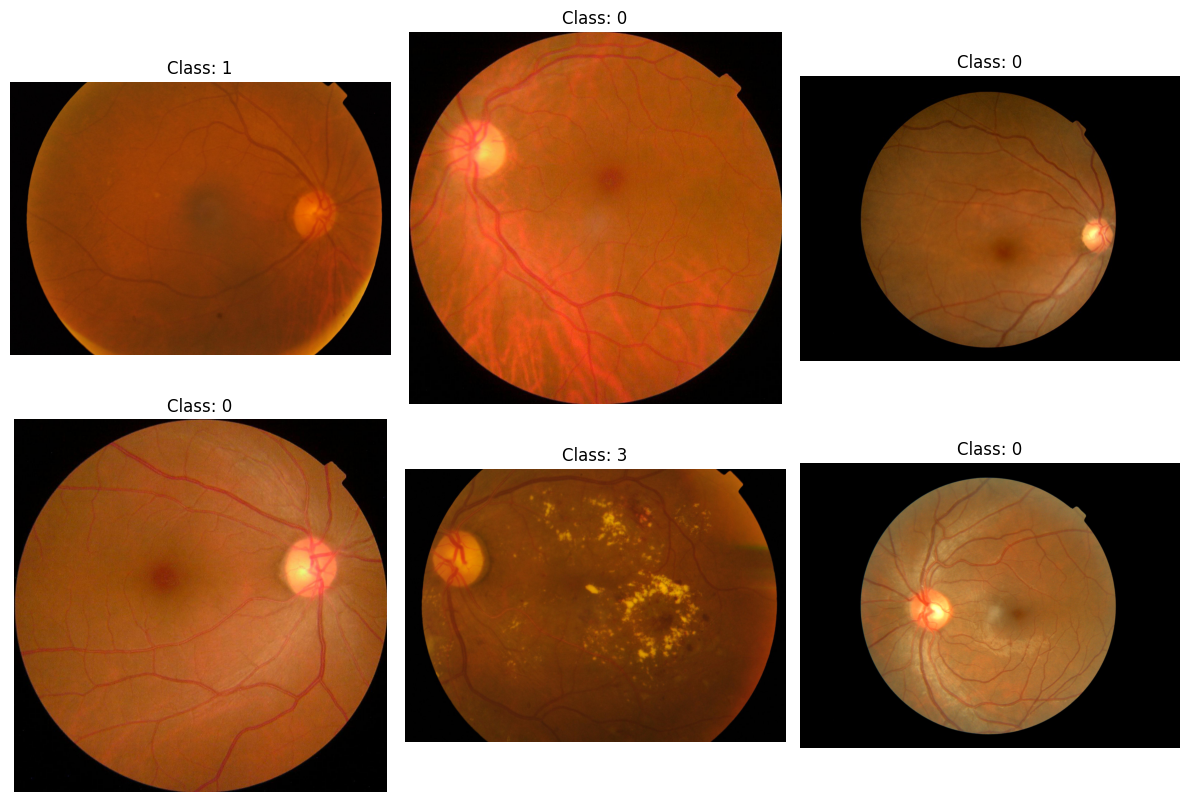

In [21]:
# ==========================================
# Display Random Retinal Images
# ==========================================

sample_df = train_df.sample(6, random_state=42)

plt.figure(figsize=(12,12))

for i, (_, row) in enumerate(sample_df.iterrows()):
    image = cv2.imread(row["image_path"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(f"Class: {row['diagnosis']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
# ==========================================
# EfficientNet Preprocessing
# ==========================================

from tensorflow.keras.applications.efficientnet import preprocess_input

IMAGE_SIZE = 224

In [23]:
# ==========================================
# Image Loading Function
# ==========================================

def load_image(image_path):
    """
    Reads an image, converts it to RGB,
    resizes it, and applies EfficientNet preprocessing.
    """

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))

    image = preprocess_input(image.astype(np.float32))

    return image

In [24]:
sample_image = train_df.iloc[0]["image_path"]

processed_image = load_image(sample_image)

print(processed_image.shape)
print(processed_image.dtype)

(224, 224, 3)
float32


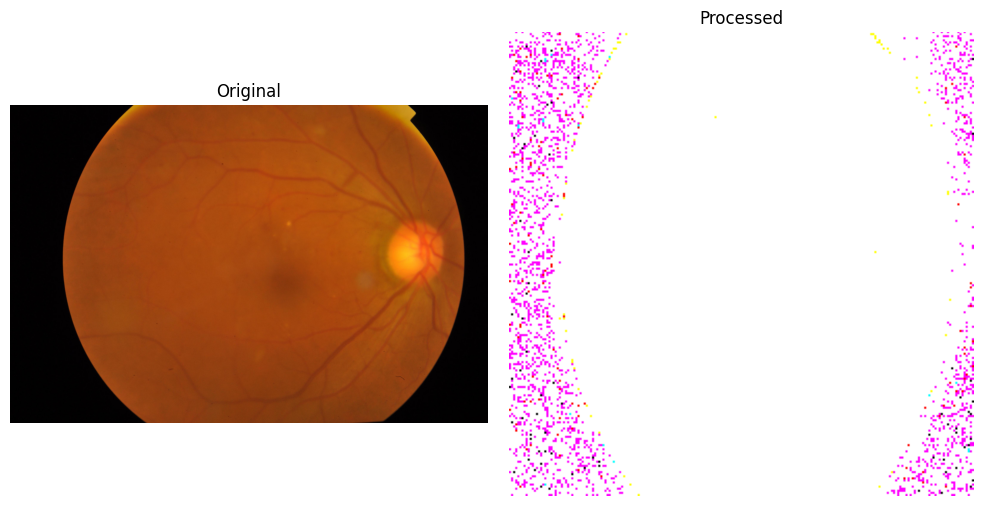

In [25]:
original = cv2.imread(sample_image)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

processed = load_image(sample_image)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed)
plt.title("Processed")
plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
print("Original Shape :", original.shape)
print("Processed Shape:", processed.shape)

Original Shape : (2136, 3216, 3)
Processed Shape: (224, 224, 3)


# 5. Data Augmentation

Deep learning models perform better when they see slightly different versions of the same image during training.

Data augmentation artificially creates new variations of the training images by applying random transformations such as:

- Horizontal flipping
- Rotation
- Zooming
- Contrast adjustment

This helps reduce overfitting and improves generalization.

In [27]:
# ==========================================
# Data Augmentation
# ==========================================

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
])

print("✅ Data Augmentation Pipeline Created")

✅ Data Augmentation Pipeline Created


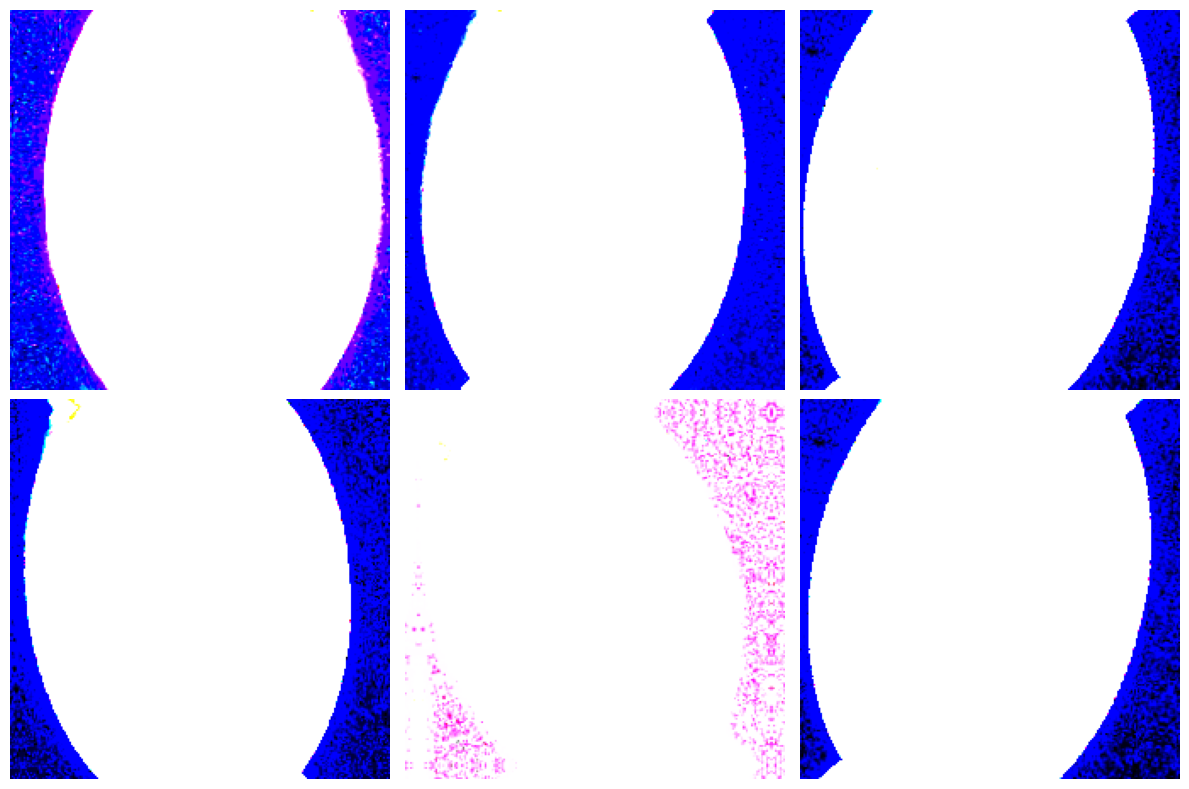

In [28]:
sample = load_image(train_df.iloc[0]["image_path"])

plt.figure(figsize=(12,8))

for i in range(6):

    augmented = data_augmentation(
        tf.expand_dims(sample, axis=0),
        training=True
    )

    plt.subplot(2,3,i+1)

    plt.imshow(augmented[0])

    plt.axis("off")

plt.tight_layout()

plt.show()


# 6. TensorFlow Data Pipeline

Instead of loading images one by one during training, TensorFlow uses an efficient `tf.data.Dataset` pipeline.

Benefits:

- Faster loading
- Better GPU utilization
- Lower memory usage
- Parallel preprocessing

In [29]:
# ==========================================
# Project Configuration
# ==========================================

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5

SEED = 42

AUTOTUNE = tf.data.AUTOTUNE

In [30]:
train_paths = train_df["image_path"].values
train_labels = train_df["diagnosis"].values

valid_paths = valid_df["image_path"].values
valid_labels = valid_df["diagnosis"].values

test_paths = test_df["image_path"].values
test_labels = test_df["diagnosis"].values

In [31]:
# ==========================================
# Create TensorFlow Datasets
# ==========================================

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

valid_dataset = tf.data.Dataset.from_tensor_slices(
    (valid_paths, valid_labels)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

print("✅ TensorFlow datasets created successfully!")

✅ TensorFlow datasets created successfully!


In [32]:
# ==========================================
# TensorFlow Image Loading & Preprocessing
# ==========================================

def load_and_preprocess_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize(image, IMAGE_SIZE)

    image = tf.keras.applications.efficientnet.preprocess_input(image)

    return image, label

In [33]:
train_dataset = train_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=AUTOTUNE
)

valid_dataset = valid_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=AUTOTUNE
)

test_dataset = test_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=AUTOTUNE
)

print("✅ Preprocessing applied.")

✅ Preprocessing applied.


In [34]:
train_dataset = (
    train_dataset
    .shuffle(buffer_size=1000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

valid_dataset = (
    valid_dataset
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    test_dataset
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [35]:
train_dataset = train_dataset.map(
    lambda images, labels: (data_augmentation(images, training=True), labels),
    num_parallel_calls=AUTOTUNE
)

In [36]:
for images, labels in train_dataset.take(1):
    print("Image Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)
    print("Image Data Type   :", images.dtype)
    print("Label Data Type   :", labels.dtype)

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)
Image Data Type   : <dtype: 'float32'>
Label Data Type   : <dtype: 'int64'>


# 7. Build EfficientNetB0 Model

In this section, we use Transfer Learning with EfficientNetB0 pretrained on ImageNet.

Why Transfer Learning?

- Faster convergence
- Better feature extraction
- Higher accuracy with limited data
- Reduced training time

Initially, the pretrained backbone is frozen, and only the custom classification head is trained.

In [37]:
# ==========================================
# Model Imports
# ==========================================

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [38]:
# ==========================================
# EfficientNetB0 Backbone
# ==========================================

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all pretrained layers
base_model.trainable = False

print("✅ EfficientNetB0 Loaded Successfully")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ EfficientNetB0 Loaded Successfully


In [39]:
# ==========================================
# Build Complete Model
# ==========================================

from tensorflow.keras.layers import BatchNormalization

inputs = Input(shape=(224, 224, 3))

# Data Augmentation
x = data_augmentation(inputs)

# Feature Extractor
x = base_model(x, training=False)

# Classification Head
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dropout(0.3)(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

print("✅ Model Created Successfully")

✅ Model Created Successfully


In [40]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,912 (16.72 MB)

 Trainable params: 331,781 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [41]:
# ==========================================
# Compile Model
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy"
    ]
)

print("✅ Model Compiled Successfully")

✅ Model Compiled Successfully


In [43]:
# ==========================================
# Training Callbacks
# ==========================================
import os
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

MODEL_DIR = "/content/drive/MyDrive/Diabetic-Retinopathy-Detection/models"
os.makedirs(MODEL_DIR, exist_ok=True)

checkpoint = ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, "best_efficientnetb0.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

callbacks = [
    early_stopping,
    reduce_lr,
    checkpoint
]

print("✅ Callbacks Ready")

✅ Callbacks Ready


In [44]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3290 - loss: 2.0470
Epoch 1: val_accuracy improved from None to 0.68579, saving model to /content/drive/MyDrive/Diabetic-Retinopathy-Detection/models/best_efficientnetb0.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Diabetic-Retinopathy-Detection/models/best_efficientnetb0.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 598s 6s/step - accuracy: 0.4672 - loss: 1.6013 - val_accuracy: 0.6858 - val_loss: 1.0808 - learning_rate: 1.0000e-04
Epoch 2/20
91/92 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.6261 - loss: 1.0940
Epoch 2: val_accuracy improved from 0.68579 to 0.74044, saving model to /content/drive/MyDrive/Diabetic-Retinopathy-Detection/models/best_efficientnetb0.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Diabetic-Retinopathy-Detection/models/best_efficientnetb0.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.6491 - loss: 1.0459 - val_accuracy: 0.7404 - val_loss: 0.8951 - learning_rate

In [45]:
import os

print(os.listdir("/content/drive/MyDrive/Diabetic-Retinopathy-Detection/models"))

['best_efficientnetb0.keras']


In [46]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/Diabetic-Retinopathy-Detection/models/best_efficientnetb0.keras"
)

print("✅ Best Model Loaded Successfully")

✅ Best Model Loaded Successfully


In [47]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 82s 6s/step - accuracy: 0.7842 - loss: 0.6240
Test Loss     : 0.6240
Test Accuracy : 0.7842


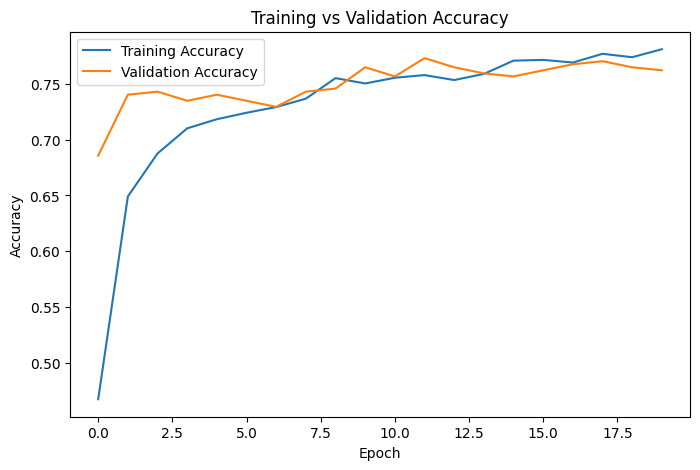

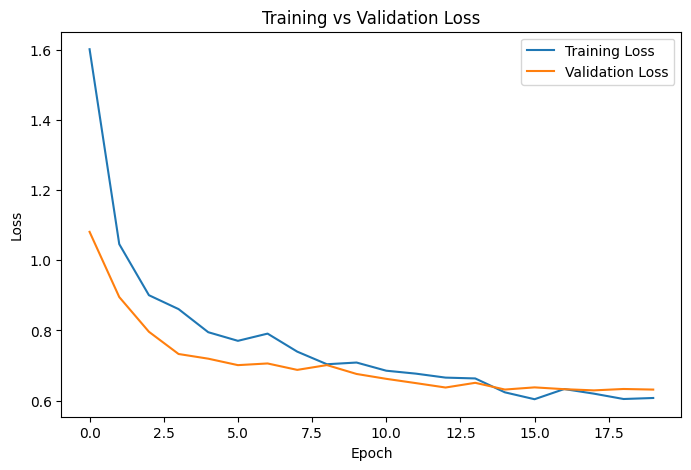

In [48]:
# ==========================================
# Plot Accuracy & Loss Curves
# ==========================================

import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# Loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [49]:
predictions = model.predict(test_dataset)

y_pred = np.argmax(predictions, axis=1)

y_true = np.concatenate(
    [labels.numpy() for _, labels in test_dataset]
)

12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step


In [51]:
# ==========================================
# Classification Report
# ==========================================

from sklearn.metrics import classification_report

class_names = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                  precision    recall  f1-score   support

           No DR       0.96      0.95      0.96       199
            Mild       0.38      0.27      0.31        30
        Moderate       0.62      0.93      0.74        87
          Severe       0.38      0.18      0.24        17
Proliferative DR       0.62      0.15      0.24        33

        accuracy                           0.78       366
       macro avg       0.59      0.50      0.50       366
    weighted avg       0.77      0.78      0.76       366



In [52]:
import os

MODEL_DIR = "/content/drive/MyDrive/Diabetic-Retinopathy-Detection/models"
os.makedirs(MODEL_DIR, exist_ok=True)

model.save(
    os.path.join(MODEL_DIR, "diabetic_retinopathy_model.keras")
)

print("✅ Final Model Saved")

✅ Final Model Saved


In [56]:
def predict_image(image_path):
    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    original_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = cv2.resize(original_image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image.astype(np.float32))
    image = np.expand_dims(image, axis=0)

    prediction = model.predict(image, verbose=0)

    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    print(f"Prediction : {class_names[predicted_class]}")
    print(f"Confidence : {confidence*100:.2f}%\n")

    print("Class Probabilities:")
    for name, prob in zip(class_names, prediction[0]):
        print(f"{name:<20}: {prob*100:.2f}%")

    plt.imshow(original_image)
    plt.title(f"Prediction: {class_names[predicted_class]}")
    plt.axis("off")
    plt.show()

    return predicted_class, confidence, prediction

Prediction : Moderate
Confidence : 75.60%

Class Probabilities:
No DR               : 1.15%
Mild                : 12.55%
Moderate            : 75.60%
Severe              : 5.89%
Proliferative DR    : 4.81%


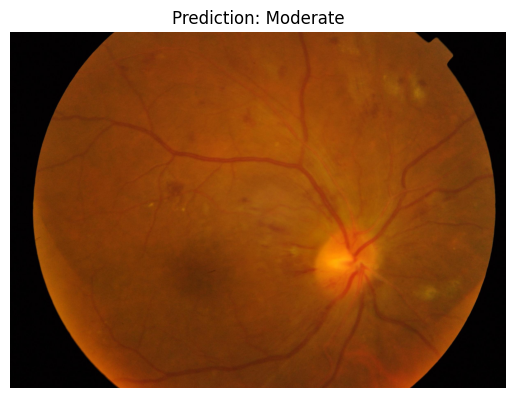

(np.int64(2),
 np.float32(0.7559948),
 array([[0.01149378, 0.12552339, 0.7559948 , 0.05890119, 0.04808678]],
       dtype=float32))

In [57]:
predict_image("/content/drive/MyDrive/Diabetic-Retinopathy-Detection/dataset/test_images/test_images/e756495c11cb.png")